#ML4Net - Lab 1

## Team members

Anna Vilacis (286004) | Martina Frisach (285336) | Aina Tolsanass (284017)

## Description

In this lab, you are going to get introduced into Multi-Armed Bandits (MABs) and Wi-Fi simulations. More specifically, you are going to implement a MAB algorithm that performs channel allocation in an Overlapping Basic Service Set (OBSS), i.e., in a scenario where multiple independent BSSs coexist.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 8 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Download the Simulator's source code

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip

--2026-05-08 10:45:33--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip [following]
--2026-05-08 10:45:34--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979661 (957K) [application/zip]
Saving to: ‘Komondor-lightweight.zip.6’

Komondor-lightweigh 100%[===================>] 956.70K  --.-KB/s    in 0.05s 

3. Define the main path of the code

In [ ]:
mypath="/content/drive/Shareddrives/ML4N/LAB1"

4. Extract the source code

In [ ]:
mkdir $mypath; cp Komondor-lightweight.zip $mypath; cd $mypath; unzip Komondor-lightweight.zip

mkdir: cannot create directory ‘/content/drive/Shareddrives/ML4N/LAB1’: File exists
Archive:  Komondor-lightweight.zip
replace config_models? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
  inflating: main/komondor_main      


5. Give permissions to run the code

In [ ]:
!sudo apt-get install -y lib32stdc++6

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
lib32stdc++6 is already the newest version (12.3.0-1ubuntu1~22.04.3).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!cd $mypath/; chmod -R 777 *

6. Compile the code

In [ ]:
!cd $mypath/main; ./build_local

In [ ]:
#imports
import matplotlib.pyplot as plt
import pandas as pd
import re

## How to run simulations

Komondor can be run by calling its compiled main file ("komondor_main") and indicating the value for different flags.

Next, you will see two different ways of running Komondor, depending on whether MAB Agents are instantiated or not.

In any case, **it is important to know** that:


*   Any input files used by the simulator will be located in the `/input` folder.
*   Any output files generated by the simulator will be located in the `/output` folder.

Apart from that, Komondor generates a set of console logs that give meaningful information.


### 1) Simulations without agents

To simulate specific scenarios (described using "input node" files) **without agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
# RUN THE SIMULATION

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_test.txt
  - simulation_code: AAX-LAB1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input file '../input/

### 2) Simulations with agents (used for keeping track of temporary performance)

To simulate specific scenarios (described using "input node" files) **with agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=0

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

Run the simulation

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

## EXERCISES

### Exercise 1:
Run the simulator (without agents) for the provided input nodes file (`/input/input_nodes.csv`). Before running the simulation, activate the flag that allows saving node logs into a file. After running the simulation, use the information from the log files of each node (e.g., AP_A, STA_A1, AP_B, STA_B1) to plot the scenario. To make the plot, consider the position of the nodes, the channel used, and the power strength that each node perceives from each other node in the deployment.

*Note: To know the power strength perceived by a given device (e.g., AP A) from any other devices (e.g., STA A1, AP B, STA B1), check the logs of that node and identify the cases where other nodes are detected to start/stop a transmission.*

In [ ]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
# RUN THE SIMULATION

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED

#La simulation el que fa és guardar informaicó dels nodes en fitxers de text anomenats "logs".


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_test.txt
  - simulation_code: AAX-LAB1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input file '../input/

In [ ]:
#LLEGIM LA INFORMACIÓ MANUALMENT
# AP_A:
# - Position: (0.00, 0.00, 0.00)
# - Chanel: 0
# - Power:
#     - STA_A1: -69.65 dBm
#     - AP_B: -72.33 dBm
#     - STA_B1: -75.33 dBm
# STA_A1:
# - Position: (0.00, 4.00, 0.00)
# - Chanel: 0
# - Power:
#     - AP_A: -69.65 dBm
#     - AP_B: -75.33 dBm
#     - STA_B1:-72.33 dBm
# AP_B:
# - Position: (5.00, 0.00, 0.00)
# - Chanel: 0
# - Power:
#     - AP_A: -72.33 dBm
#     - STA_A1: -75.33 dBm
#     - STA_B1: -69.65 dBm
# STA_B1:
# - Position: (5.00, 4.00, 0.00)
# - Chanel: 0
# - Power:
#     - AP_A:-75.33 dBm
#     - STA_A1: -72.33 dBm
#     - AP_B: -69.65 dBm

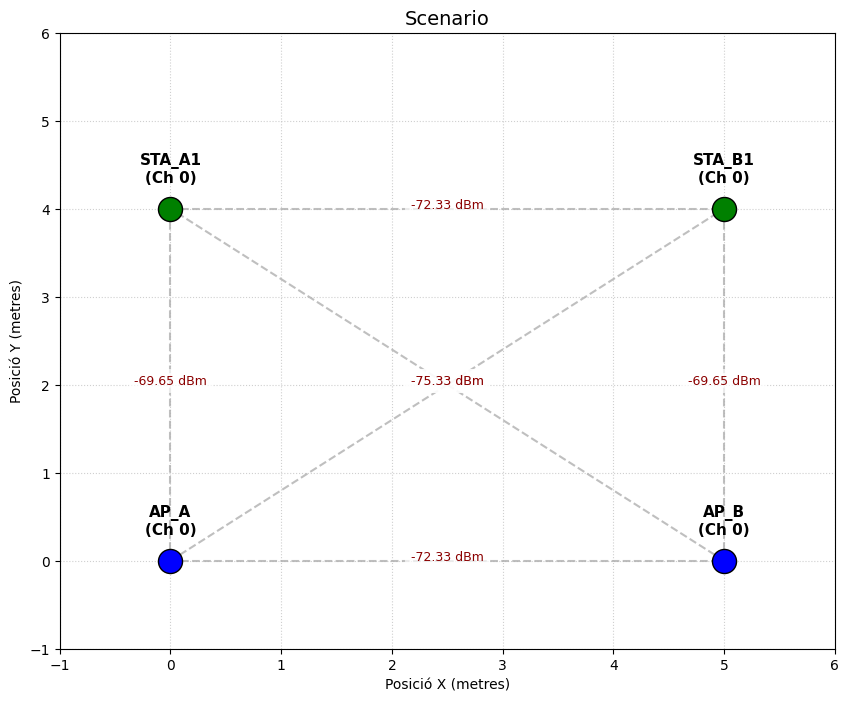

In [ ]:
# Agafem els valors manualment dels fitxers obtinguts
nodes = {
    'AP_A': (0, 0),
    'STA_A1': (0, 4),
    'AP_B': (5, 0),
    'STA_B1': (5, 4)
}

connections = [
    ('AP_A', 'STA_A1', -69.65),
    ('AP_B', 'STA_B1', -69.65),
    ('AP_A', 'AP_B', -72.33),
    ('STA_A1', 'STA_B1', -72.33),
    ('AP_A', 'STA_B1', -75.33),
    ('AP_B', 'STA_A1', -75.33)
]

fig, ax = plt.subplots(figsize=(10, 8))

for n1, n2, pwr in connections:
    x_coords = [nodes[n1][0], nodes[n2][0]]
    y_coords = [nodes[n1][1], nodes[n2][1]]

    ax.plot(x_coords, y_coords, color='gray', linestyle='--', alpha=0.5, zorder=1)

    mid_x = sum(x_coords) / 2
    mid_y = sum(y_coords) / 2
    ax.text(mid_x, mid_y, f"{pwr} dBm", fontsize=9, ha='center', color='darkred',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for name, (x, y) in nodes.items():
    color = 'blue' if 'AP' in name else 'green'
    ax.scatter(x, y, s=300, color=color, edgecolors='black', zorder=2)
    ax.text(x, y + 0.3, f"{name}\n(Ch 0)", ha='center', fontsize=11, fontweight='bold')

ax.set_title("Scenario", fontsize=14)
ax.set_xlabel("Posició X (metres)")
ax.set_ylabel("Posició Y (metres)")
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

Veiem com la imatge mostra l'escenari de la xarxa Wi-Fi amb els 4 nodes distribuits en l'espai de 2 dimensions.

Veiem els 2 AP (routers WiFi) i els 2 stations (que poden ser clients com ara un portatil). Veiem com tots operen al canal 0, ja que és el que s'especifica en el input_nodes.

També podem veure com les connexions entre ap_x i st_x son mes bones que les altres connexions. Quant més negatiu el dBm, menor és la potencia rebuda (pitjor senyal). Això es degut a la distancia entre els nodes.

### Exercise 2:

Run the simulator (this time, with agents in "monitor" mode) for the provided input nodes file (`/input/input_nodes.csv`). The input agents file to be used is provided as (`/input/agents_monitoring.csv`). Ensure that the agent logs are saved into files by setting the corresponding flag to 1. After running the simulation, use the agent log files to plot the temporary throughput obtained by each AP.

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

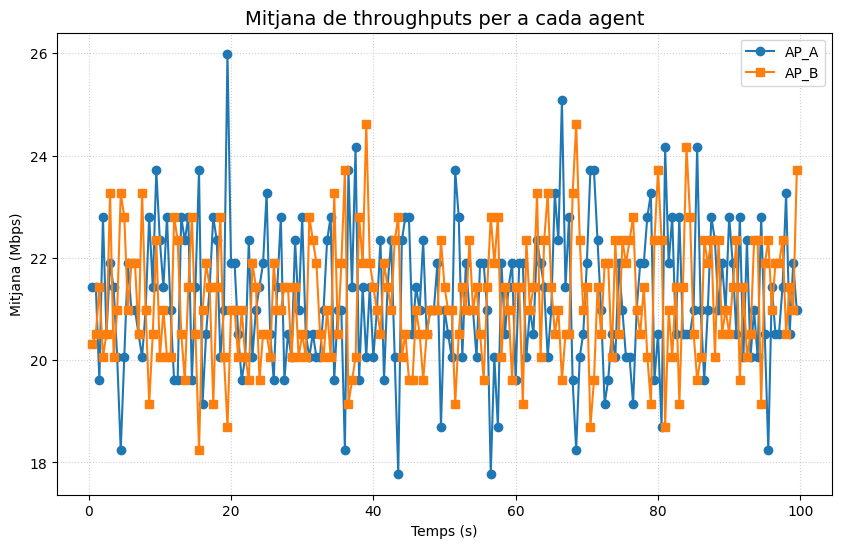

In [ ]:
agent_A_path = mypath + "/output/logs_output_AAX-LAB1-AGENTS_A0_A.txt"
agent_B_path = mypath + "/output/logs_output_AAX-LAB1-AGENTS_A1_B.txt"

#funció per extreure el throughput
def extreure_throughput(path_fitxer):

    temps = [] #On guardarem el temps
    throughputs = [] #On guardem els throughputs

    with open(path_fitxer, "r") as f:
        for linia in f:
            if "Average throughput" in linia:
                parts = linia.split(";") #dividim per obtenir el valor. Va abans del ;
                t = float(parts[0])
                match = re.search(r"Average throughput\s*=\s*([0-9.]+)", linia) #Busquem el número del throughput
                if match:
                    thr = float(match.group(1))
                    temps.append(t) #afegim valors
                    throughputs.append(thr) #afegim valors

    return temps, throughputs

#agafem els valors per cada agent
temps_A, throughput_A = extreure_throughput(agent_A_path)
temps_B, throughput_B = extreure_throughput(agent_B_path)

#Plotegem
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(temps_A, throughput_A, marker='o', label='AP_A')
ax.plot(temps_B, throughput_B, marker='s', label='AP_B')

ax.set_title("Mitjana de throughputs per a cada agent", fontsize=14)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Mitjana (Mbps)")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.show()


Al plot podem veure throughput temporal (rendiment) observat pels agents dels 2 AP durant un interval de temps.

Veiem com el throughput de les dues xarxes son sembants ja que oscil·len entre valors similars i amb una mitjana de 22Mbps. Això es degut a que son simetriques (mateix canal, distancia i potencia).

Sabem que hi ha interferencies entre els 2 APs ja que els dos operen al mateix canal. Si no hi hagues això, podrien obtenir un throughput més alt.

També podem veure que quan un AP puja, l'altre baixa, degut a que comparteixen el medi.

### Exercise 3:

Copy the `agents_monitoring.csv` file, rename it as `agents_egreedy.csv`, and modify it as follows:
- Indicate the possible "channel actions" by indicating `0,1` in the column 'actions channels' of each agent.
- Set the colum "learning mechanism" to `1`(which stands for multi-armed bandits) for each agent.
- Set the column "selected strategy" to `1` (which stands for ɛ-greedy) for each agent.

Then, run the simulation using `agents_egreedy.csv` and plot the temporary throughput obtained by each AP, as done in Exercise 2. In addition, read the console logs from Komondor and explain the displayed agent logs.

**Important:** In case of experiencing a run-time error, check that the fields in the 'agents' file are separated by a semicolon (`;`).

In [ ]:
agents_monitoring_path = mypath + "/input/agents_monitoring.csv"
agents_egreedy_path = mypath + "/input/agents_egreedy.csv"

agents_df = pd.read_csv(agents_monitoring_path, sep=";")

#canviem els valors
agents_df["actions channels"] = "0,1"
agents_df["learning mechanism"] = 1
agents_df["selected_strategy"] = 1

agents_df.to_csv(agents_egreedy_path, sep=";", index=False)
display(agents_df)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1


In [ ]:
# DEFINIM ELS ARGUMENTS DE LA SIMULACIÓ PER E-GREEDY

INPUT_FILE_NODES = '../input/input_nodes.csv'
INPUT_FILE_AGENTS = '../input/agents_egreedy.csv'

OUTPUT_FILE_LOGS = '../output/logs_test_egreedy.txt'
SIMULATION_CODE = 'AAX-LAB1-EGREEDY'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

In [ ]:
#cridem la simulació
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy.csv
  - script_output_filename: ../output/logs_test_egreedy.txt
  - simulation_code: AAX-LAB1-EGREEDY
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EGREEDY.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

In [ ]:
#Creem una funció per extreure els valors que necessitem
def extract_metrics_from_log(path):
    times = []
    throughputs = []
    rewards = []
    channels = []

    #variables temporals ja que la info d'un instant esta en diverses linees
    current_time = None
    current_channel = None
    current_throughput = None

    with open(path, "r") as f:
        for line in f:
            parts = line.split(";") #dividim en 4 parts perque hi ha 4 valors per extreure separats per ;
            if len(parts) < 4:
                continue
            time = float(parts[0])

            #anem obtenint les metriques segons a la fila que es troba fins tenir el reward
            if "channel =" in line:
                match = re.search(r"channel\s*=\s*([0-9]+)", line)
                if match:
                    current_time = time
                    current_channel = int(match.group(1))

            if "Average throughput" in line:
                match = re.search(r"Average throughput\s*=\s*([0-9.]+)", line)
                if match:
                    current_time = time
                    current_throughput = float(match.group(1))

            if "Associated reward" in line:
                match = re.search(r"Associated reward\s*=\s*([0-9.]+)", line)
                if match:
                    reward = float(match.group(1))

                    times.append(current_time)
                    channels.append(current_channel)
                    throughputs.append(current_throughput)
                    rewards.append(reward)

    return pd.DataFrame({
        "time": times,
        "channel": channels,
        "throughput": throughputs,
        "reward": rewards
    })

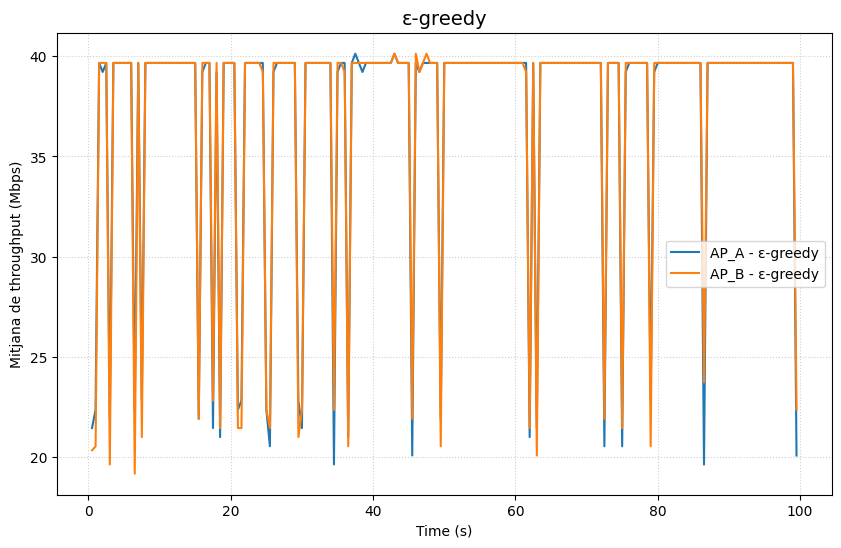

In [ ]:
agent_A_path = mypath + "/output/logs_output_AAX-LAB1-EGREEDY_A0_A.txt"
agent_B_path = mypath + "/output/logs_output_AAX-LAB1-EGREEDY_A1_B.txt"

#extraiem els valors
df_A = extract_metrics_from_log(agent_A_path)
df_B = extract_metrics_from_log(agent_B_path)

#Plotegem en funció del temps
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_A["time"], df_A["throughput"], label="AP_A - ε-greedy")
ax.plot(df_B["time"], df_B["throughput"], label="AP_B - ε-greedy")

ax.set_title("ε-greedy", fontsize=14)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mitjana de throughput (Mbps)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.show()

Com ara els agents també aprenen i actuen mitjançant e-greedy, cada agent pot escollir entre el canal 0 i el canal 1 i llavors apren quin canal li dona més throughput.

Quan hi ha throughput alts, vol dir que els APs estan en canals diferents, mentre que si els tenen baixos, els canals son iguals (amb interferencies). Llavors les caigudes passen quan l'agent esta explorant (tria un canal aleatori enlloc del millor). Si els dos acaben al mateix canal a la vegada, el throughput cau a la meitat.

No obstant, podem observar que la gran majoria te throughputs alts però no gaire constants, això vol dir que l'agent va canviant de canal. Veiem que cada vegada va a menys el canvi de canal però no s'acaba estabilitzant del tot.

També podem veure com els 2 APs es mouen junts, ja que quan un canvia de canal afecta a l'altre.

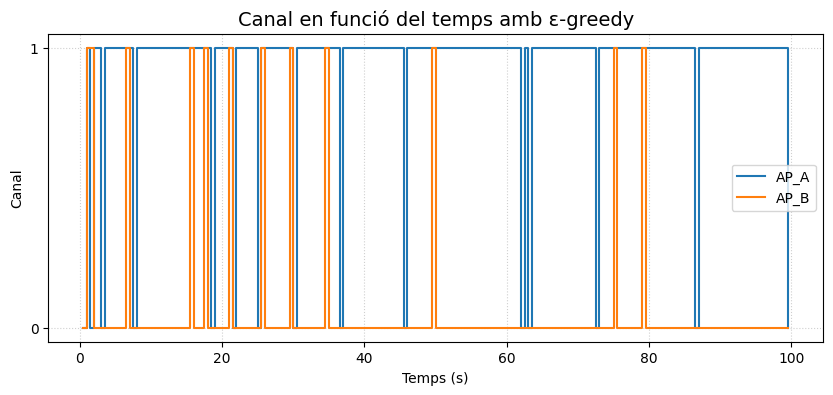

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.step(df_A["time"], df_A["channel"], where="post", label="AP_A")
ax.step(df_B["time"], df_B["channel"], where="post", label="AP_B")

#Plotegem en funció del canal
ax.set_title("Canal en funció del temps amb ε-greedy", fontsize=14)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Canal")
ax.set_yticks([0, 1])
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.show()

En aquesta imatge veiem la sel·lecció de canal i explica perfectament el que hem vist abans.

### Exercise 4:
Create another input agents file (name it `agents_ml4net.csv`), but this time set the column "selected_strategy" (the last one) to 5.

The mechanism (as it is currently implemented) will just select actions randomly. For that reason, you have to define your own action-selection strategy by completing the code in `/learning_modules/network_optimization_methods/multi_armed_bandits.h`. More specifically, you will have to complete the function `PickArmML4Net()`, which contains all the logic. You can get inspiration from the other implemented MAB algorithms (e.g., UCB, Thompson sampling).

**IMPORTANT:** If you modify the source code, you will have to re-compile it (see step 6 in "Setting up the environment") before running new simulations.

In [ ]:
agents_egreedy_path = mypath + "/input/agents_egreedy.csv"
agents_ml4net_path = mypath + "/input/agents_ml4net.csv"

agents_df = pd.read_csv(agents_egreedy_path, sep=";")

#Definim la selected_strategy a 5 tal com se'ns diu a l'enunciat
agents_df["selected_strategy"] = 5

agents_df.to_csv(agents_ml4net_path, sep=";", index=False)
display(agents_df)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,5
1,B,0,0.5,"0,1",-82,15,1,2,1,5


In [ ]:
INPUT_FILE_NODES = '../input/input_nodes.csv'
INPUT_FILE_AGENTS = '../input/agents_ml4net.csv'

OUTPUT_FILE_LOGS = '../output/logs_test_ml4net.txt'
SIMULATION_CODE = 'AAX-LAB1-ML4NET'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

In [ ]:
#cridem la simulació
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net.csv
  - script_output_filename: ../output/logs_test_ml4net.txt
  - simulation_code: AAX-LAB1-ML4NET
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-ML4NET.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINIST

In [ ]:
#Creem la funció per extreure informació dels logs
def extract_metrics_from_log(path):
    #On guardarem els valors
    times = []
    throughputs = []
    rewards = []
    channels = []

    current_time = None
    current_channel = None
    current_throughput = None

    with open(path, "r") as f:
        for line in f:
            parts = line.split(";")

            if len(parts) < 4:
                continue

            time = float(parts[0])

            if "channel =" in line:
                match = re.search(r"channel\s*=\s*([0-9]+)", line)
                if match:
                    current_time = time
                    current_channel = int(match.group(1))

            if "Average throughput" in line:
                match = re.search(r"Average throughput\s*=\s*([0-9.]+)", line)
                if match:
                    current_time = time
                    current_throughput = float(match.group(1))

            if "Associated reward" in line:
                match = re.search(r"Associated reward\s*=\s*([0-9.]+)", line)
                if match:
                    reward = float(match.group(1))

                    times.append(current_time)
                    channels.append(current_channel)
                    throughputs.append(current_throughput)
                    rewards.append(reward)

    return pd.DataFrame({
        "time": times,
        "channel": channels,
        "throughput": throughputs,
        "reward": rewards
    })

In [ ]:
agent_A_ml4net_path = mypath + "/output/logs_output_AAX-LAB1-ML4NET_A0_A.txt"
agent_B_ml4net_path = mypath + "/output/logs_output_AAX-LAB1-ML4NET_A1_B.txt"

#Extraiem informació
df_A_ml4net = extract_metrics_from_log(agent_A_ml4net_path)
df_B_ml4net = extract_metrics_from_log(agent_B_ml4net_path)

print("AP_A samples:", len(df_A_ml4net))
print("AP_B samples:", len(df_B_ml4net))

AP_A samples: 199
AP_B samples: 199


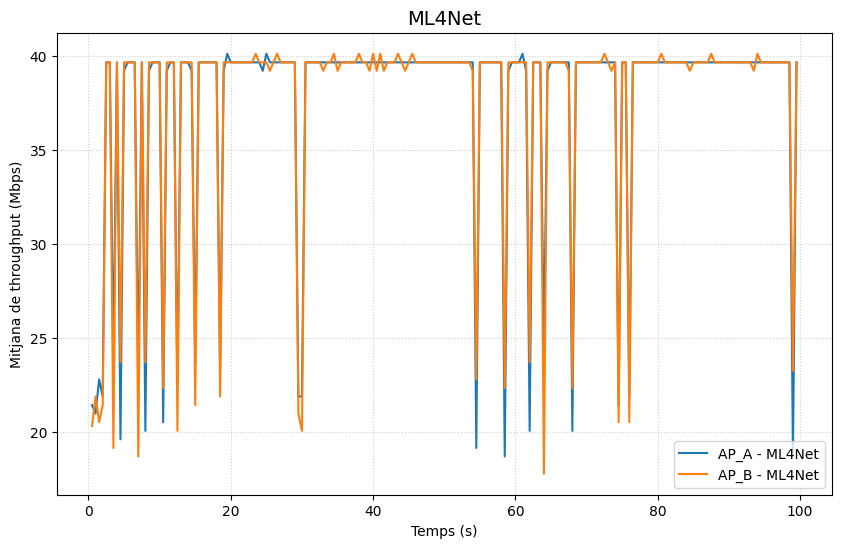

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_A_ml4net["time"], df_A_ml4net["throughput"], label="AP_A - ML4Net")
ax.plot(df_B_ml4net["time"], df_B_ml4net["throughput"], label="AP_B - ML4Net")

#Plotegem en funció del temps
ax.set_title("ML4Net", fontsize=14)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Mitjana de throughput (Mbps)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.show()

Aquí observem el mateix comportament que en el cas anterior, però aplicant l'algoritme ML4Net. Podem veure que l'agent no canvia de canal tan sovint, cosa que indica que l'estratègia convergeix millor que l'e-greedy. Els AP passen més estona en canals diferents de manera més constant, evitant així les interferències entre ells. Tot i que s'aprecia una fase inicial on els AP canvien de canal constantment, finalment el sistema s'estabilitza i manté un nivell de throughput molt més constant.  

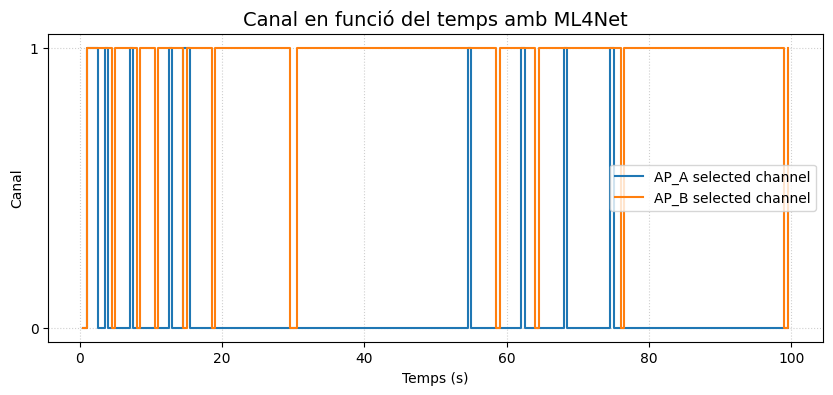

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.step(df_A_ml4net["time"], df_A_ml4net["channel"], where="post", label="AP_A selected channel")
ax.step(df_B_ml4net["time"], df_B_ml4net["channel"], where="post", label="AP_B selected channel")

#Plotegem en funció del canal
ax.set_title("Canal en funció del temps amb ML4Net", fontsize=14)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Canal")
ax.set_yticks([0, 1])
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.show()

In [ ]:
mean_A_egreedy = df_A["throughput"].mean()
mean_B_egreedy = df_B["throughput"].mean()
total_egreedy = mean_A_egreedy + mean_B_egreedy

mean_A_ml4net = df_A_ml4net["throughput"].mean()
mean_B_ml4net = df_B_ml4net["throughput"].mean()
total_ml4net = mean_A_ml4net + mean_B_ml4net

print("Mitjana ε-greedy")
print("AP_A:", mean_A_egreedy, "Mbps")
print("AP_B:", mean_B_egreedy, "Mbps")
print("Total:", total_egreedy, "Mbps")

print("\nMitjana ML4Net")
print("AP_A:", mean_A_ml4net, "Mbps")
print("AP_B:", mean_B_ml4net, "Mbps")
print("Total:", total_ml4net, "Mbps")

Mitjana ε-greedy
AP_A: 37.36301507537689 Mbps
AP_B: 37.36412060301508 Mbps
Total: 74.72713567839197 Mbps

Mitjana ML4Net
AP_A: 37.63804020100503 Mbps
AP_B: 37.644070351758806 Mbps
Total: 75.28211055276384 Mbps


En aquesta gràfica veiem encara més reflectit el que s'ha explicat anteriorment. S'observa com l'algoritme ML4Net assoleix un valor de throughput superior, tant per a l'AP_A i l'AP_B com per al total. Això sí, aquesta diferència en els throughputs obtinguts en funció de l'algoritme no és gaire considerable, i encara ho és menys si comparem els agents per separat.

### Exercise 5:

Run a simulation to test your action-selection strategy. Compare it to ɛ-greedy (Exercise 3) by plotting the temporary throughput obtained by each of the mechanisms.

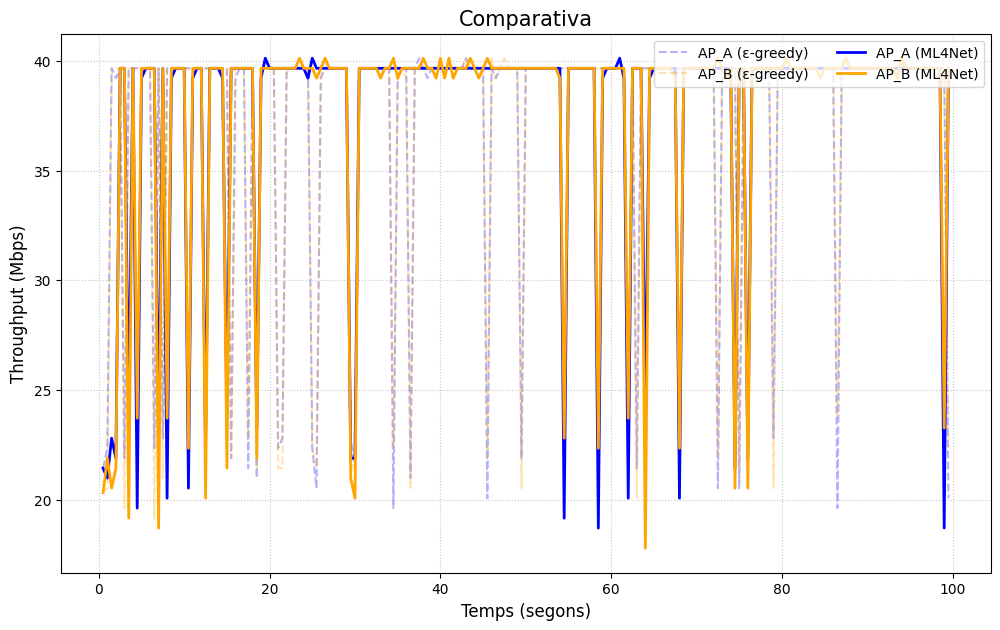

Rendiment total mitjà ε-greedy: 74.72713567839197423837 Mbps
Rendiment total mitjà ML4Net: 75.28 Mbps


In [ ]:
# Suposem que ja tenim df_A i df_B (de l'Ex 3) i df_A_ml4net i df_B_ml4net (de l'Ex 4)
fig, ax = plt.subplots(figsize=(12, 7))

# Plot e-greedy
ax.plot(df_A["time"], df_A["throughput"], label="AP_A (ε-greedy)", color='blue', alpha=0.3, linestyle='--')
ax.plot(df_B["time"], df_B["throughput"], label="AP_B (ε-greedy)", color='orange', alpha=0.3, linestyle='--')

# Plot  ML4Net
ax.plot(df_A_ml4net["time"], df_A_ml4net["throughput"], label="AP_A (ML4Net)", color='blue', linewidth=2)
ax.plot(df_B_ml4net["time"], df_B_ml4net["throughput"], label="AP_B (ML4Net)", color='orange', linewidth=2)

# Configuració estètica
ax.set_title("Comparativa", fontsize=15)
ax.set_xlabel("Temps (segons)", fontsize=12)
ax.set_ylabel("Throughput (Mbps)", fontsize=12)
ax.legend(loc='upper right', ncol=2)
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

#Plotegem rendiment mitjà
total_egreedy = df_A["throughput"].mean() + df_B["throughput"].mean()
total_ml4net = df_A_ml4net["throughput"].mean() + df_B_ml4net["throughput"].mean()

print(f"Rendiment total mitjà ε-greedy: {total_egreedy:.20f} Mbps")
print(f"Rendiment total mitjà ML4Net: {total_ml4net:.2f} Mbps")


Al gràfic veiem la velocitat mitjana de transferència (throughput) entre els diferents BSS i els punts d'accés en funció de l'algoritme que el BSS utilitza per decidir quin canal de ràdio fer servir en cada moment per maximitzar la seva velocitat.

Així doncs, comparem el valor del throughput de cada BSS per separat segons l'algoritme utilitzat. Analitzant els valors de la gràfica i el rendiment mitjà total, veiem que ML4Net dona millors resultats, ja que obté un throughput superior i més constant, amb una mitjana d'aproximadament 1 Mbps més.

### Exercise 6:

Now, modify the "input_nodes.csv" and the input agent files (`agents_egreedy.csv` and `agents_ml4net.csv`) to add a third BSS, which must use the same configuration as the other BSSs but whose AP and STA must be placed at (10,0,0) m and (10,4,0) m, respectively. In the agents file, you will also have to add a third column so that the third BSS gets an agent enrolled.

Run N=5 simulations (using different random seeds) for each action-selection strategy and plot the average throughput obtained by each BSS across the different simulations for each approach.

In [ ]:
# 1. Modificació de la topologia, afegim un BSS
input_nodes_path = mypath + '/input/input_nodes.csv'
input_nodes_3bss_path = mypath + "/input/input_nodes_3bss.csv"
nodes_df = pd.read_csv(input_nodes_path, sep=";")

ap_c = nodes_df.iloc[2].copy()
sta_c = nodes_df.iloc[3].copy()

ap_c["node_code"] = "AP_C"
sta_c["node_code"] = "STA_C1"

ap_c["wlan_code"] = "C"
sta_c["wlan_code"] = "C"

ap_c["x(m)"] = 10
ap_c["y(m)"] = 0
ap_c["z(m)"] = 0

sta_c["x(m)"] = 10
sta_c["y(m)"] = 4
sta_c["z(m)"] = 0

nodes_3bss_df = pd.concat(
    [nodes_df, pd.DataFrame([ap_c, sta_c])],
    ignore_index=True
)

nodes_3bss_df.to_csv(input_nodes_3bss_path, sep=";", index=False)

display(nodes_3bss_df)

,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
0,AP_A,0,A,0,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
1,STA_A1,1,A,0,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
2,AP_B,0,B,5,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
3,STA_B1,1,B,5,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
4,AP_C,0,C,10,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
5,STA_C1,1,C,10,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


In [ ]:
agents_path = mypath + "/input/agents_egreedy.csv"
agents_3bss_path = mypath + "/input/agents_egreedy_3bss.csv"

agents_df = pd.read_csv(agents_path, sep=";")
display(agents_df)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1


In [ ]:
agents_path = mypath + "/input/agents_egreedy.csv"
agents_3bss_path = mypath + "/input/agents_egreedy_3bss.csv"

agents_df = pd.read_csv(agents_path, sep=";")

agent_c = agents_df.iloc[1].copy()

agent_c["Wlan code"] = "C"
agent_c["actions channels"] = "0,1"
agent_c["learning mechanism"] = 1
agent_c["selected_strategy"] = 1

agents_3bss_df = pd.concat(
    [agents_df, pd.DataFrame([agent_c])],
    ignore_index=True
)

agents_3bss_df.to_csv(agents_3bss_path, sep=";", index=False)

display(agents_3bss_df)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1
2,C,0,0.5,"0,1",-82,15,1,2,1,1


In [ ]:
agents_path = mypath + "/input/agents_ml4net.csv"
agents_3bss_path = mypath + "/input/agents_ml4net_3bss.csv"

agents_df = pd.read_csv(agents_path, sep=";")

agent_c = agents_df.iloc[1].copy()

agent_c["Wlan code"] = "C"
agent_c["actions channels"] = "0,1"
agent_c["learning mechanism"] = 1
agent_c["selected_strategy"] = 5

agents_3bss_df = pd.concat(
    [agents_df, pd.DataFrame([agent_c])],
    ignore_index=True
)

agents_3bss_df.to_csv(agents_3bss_path, sep=";", index=False)

display(agents_3bss_df)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,5
1,B,0,0.5,"0,1",-82,15,1,2,1,5
2,C,0,0.5,"0,1",-82,15,1,2,1,5


In [ ]:
INPUT_FILE_NODES = '../input/input_nodes_3bss.csv'
INPUT_FILE_AGENTS = '../input/agents_egreedy_3bss.csv'

OUTPUT_FILE_LOGS = '../output/logs_test_egreedy_3bss.txt'
SIMULATION_CODE = 'AAX-LAB1-EGREEDY-3BSS'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

In [ ]:
#cridem la simulació
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_3bss.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy_3bss.csv
  - script_output_filename: ../output/logs_test_egreedy_3bss.txt
  - simulation_code: AAX-LAB1-EGREEDY-3BSS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EGREEDY-3BSS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!



In [ ]:
INPUT_FILE_NODES = '../input/input_nodes_3bss.csv'
INPUT_FILE_AGENTS = '../input/agents_ml4net_3bss.csv'

OUTPUT_FILE_LOGS = '../output/logs_test_ml4net_3bss.txt'
SIMULATION_CODE = 'AAX-LAB1-ML4NET-3BSS'

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

In [ ]:
#cridem la simulació
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_3bss.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net_3bss.csv
  - script_output_filename: ../output/logs_test_ml4net_3bss.txt
  - simulation_code: AAX-LAB1-ML4NET-3BSS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-ML4NET-3BSS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Gen

In [ ]:
#Creem una funció per llegir la mitjana de throughputs del fitxer
def get_avg_throughput(file_path):
    throughputs = []

    with open(file_path, "r") as f:
        for line in f:
            if "Average throughput" in line:
                value = re.search(r"Average throughput\s*=\s*([0-9.]+)", line)
                if value:
                    throughputs.append(float(value.group(1)))

    return sum(throughputs) / len(throughputs)

In [ ]:
logs = {
    ("ε-greedy", "A"): mypath + "/output/logs_output_AAX-LAB1-EGREEDY-3BSS_A0_A.txt",
    ("ε-greedy", "B"): mypath + "/output/logs_output_AAX-LAB1-EGREEDY-3BSS_A1_B.txt",
    ("ε-greedy", "C"): mypath + "/output/logs_output_AAX-LAB1-EGREEDY-3BSS_A2_C.txt",

    ("ML4Net", "A"): mypath + "/output/logs_output_AAX-LAB1-ML4NET-3BSS_A0_A.txt",
    ("ML4Net", "B"): mypath + "/output/logs_output_AAX-LAB1-ML4NET-3BSS_A1_B.txt",
    ("ML4Net", "C"): mypath + "/output/logs_output_AAX-LAB1-ML4NET-3BSS_A2_C.txt",
}

results = []

for (strategy, bss), path in logs.items():
    avg_thr = get_avg_throughput(path)
    results.append([strategy, bss, avg_thr])

results_df = pd.DataFrame(results, columns=["Strategy", "BSS", "Average throughput (Mbps)"])

display(results_df)


,Strategy,BSS,Average throughput (Mbps)
0,ε-greedy,A,38.261307
1,ε-greedy,B,34.221407
2,ε-greedy,C,38.187286
3,ML4Net,A,38.146633
4,ML4Net,B,34.601709
5,ML4Net,C,38.553769


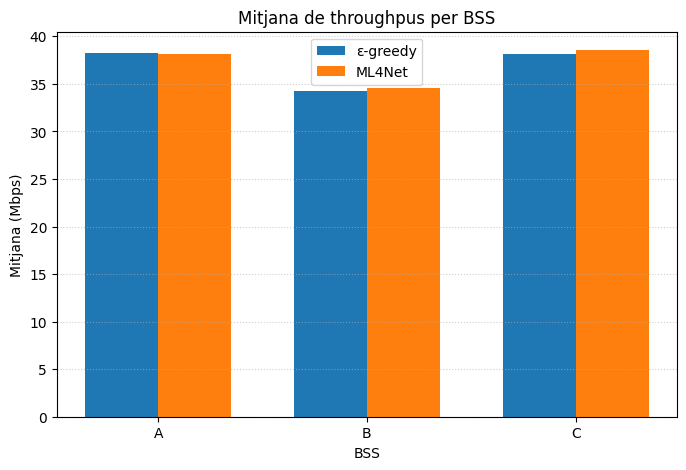

In [ ]:
# Preparar dades pel gràfic
egreedy = results_df[results_df["Strategy"] == "ε-greedy"]["Average throughput (Mbps)"].values
ml4net = results_df[results_df["Strategy"] == "ML4Net"]["Average throughput (Mbps)"].values

bss = ["A", "B", "C"]
x = range(len(bss))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar([i - width/2 for i in x], egreedy, width, label="ε-greedy")
ax.bar([i + width/2 for i in x], ml4net, width, label="ML4Net")

ax.set_title("Mitjana de throughpus per BSS")
ax.set_xlabel("BSS")
ax.set_ylabel("Mitjana (Mbps)")
ax.set_xticks(list(x))
ax.set_xticklabels(bss)
ax.grid(True, axis="y", linestyle=":", alpha=0.6)
ax.legend()

plt.show()

Al gràfic veiem la velocitat mitjana de transferència (throughput) dels diferents BSS en funció de l'algoritme utilitzat. Analitzant els valors, s'observa que l'algoritme ML4Net és més eficient que l'e-greedy, ja que obté una mitjana lleugerament més alta de throughput en els tres BSS.

D'altra banda, s'aprecia que el rendiment dels tres BSS ha baixat amb ambdós algoritmes en comparació amb l'escenari de només dos BSS. Mentre que anteriorment el valor se situava a prop dels 37 Mbps, ara es troba al voltant dels 35 Mbps o fins i tot per sota. Aquest comportament és d'esperar: en haver-hi un BSS addicional, el medi està més ocupat i hi ha més competició pel canal, fet que redueix inevitablement el throughput individual.